# Interpolation

In [ ]:
pip install plotly --quiet

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import scipy as sp
pio.renderers.default = "notebook"
import scienceplots
plt.style.use(["science"])

In [61]:
import sympy as sp
from sympy.polys.polyfuncs import interpolate
from sympy import symbols, interpolating_spline

# 1. Define your symbolic variable
x = sp.symbols('x')

## Langrage interpolation

In [62]:
x=np.linspace(0,10,20)
y=x**2+3*x+x

In [63]:
x

array([ 0.        ,  0.52631579,  1.05263158,  1.57894737,  2.10526316,
        2.63157895,  3.15789474,  3.68421053,  4.21052632,  4.73684211,
        5.26315789,  5.78947368,  6.31578947,  6.84210526,  7.36842105,
        7.89473684,  8.42105263,  8.94736842,  9.47368421, 10.        ])

In [64]:
y

array([  0.        ,   2.38227147,   5.31855956,   8.80886427,
        12.8531856 ,  17.45152355,  22.60387812,  28.31024931,
        34.57063712,  41.38504155,  48.7534626 ,  56.67590028,
        65.15235457,  74.18282548,  83.76731302,  93.90581717,
       104.59833795, 115.84487535, 127.64542936, 140.        ])

In [65]:
#plot 
plt.plot(x,y,'-o')
plt.grid(True,alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")

Text(0, 0.5, 'y')

Error in callback <function _draw_all_if_interactive at 0x000001F2565F5620> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 350x262.5 with 1 Axes>

In [66]:
#interpolation for  @x=5.263135
from scipy.interpolate import lagrange
poly=lagrange(x,y)
"""
@x=5.263158,y=48.75346
"""

#interpolated value \
interp_y=poly(5.263158)
np.round(interp_y,6)

np.float64(48.752899)

Approximated value of interpolation is not exact to the true value


### Using Different Methods

In [8]:
from scipy.interpolate import interp1d

#### Linear

In [9]:
poly=interp1d(x,y,kind='linear');
poly(5)

array(45.06925208)

### quadratic

In [10]:
poly=interp1d(x,y,kind='quadratic')
poly(5)

array(45.)

### Cubic

In [11]:
poly=interp1d(x,y,kind='cubic')
poly(5)

array(45.)

### Spline

In [12]:
from scipy.interpolate import UnivariateSpline
poly=UnivariateSpline(x,y,k=3)
poly(5)

array(45.)

## Digital to Analog Reonstruction

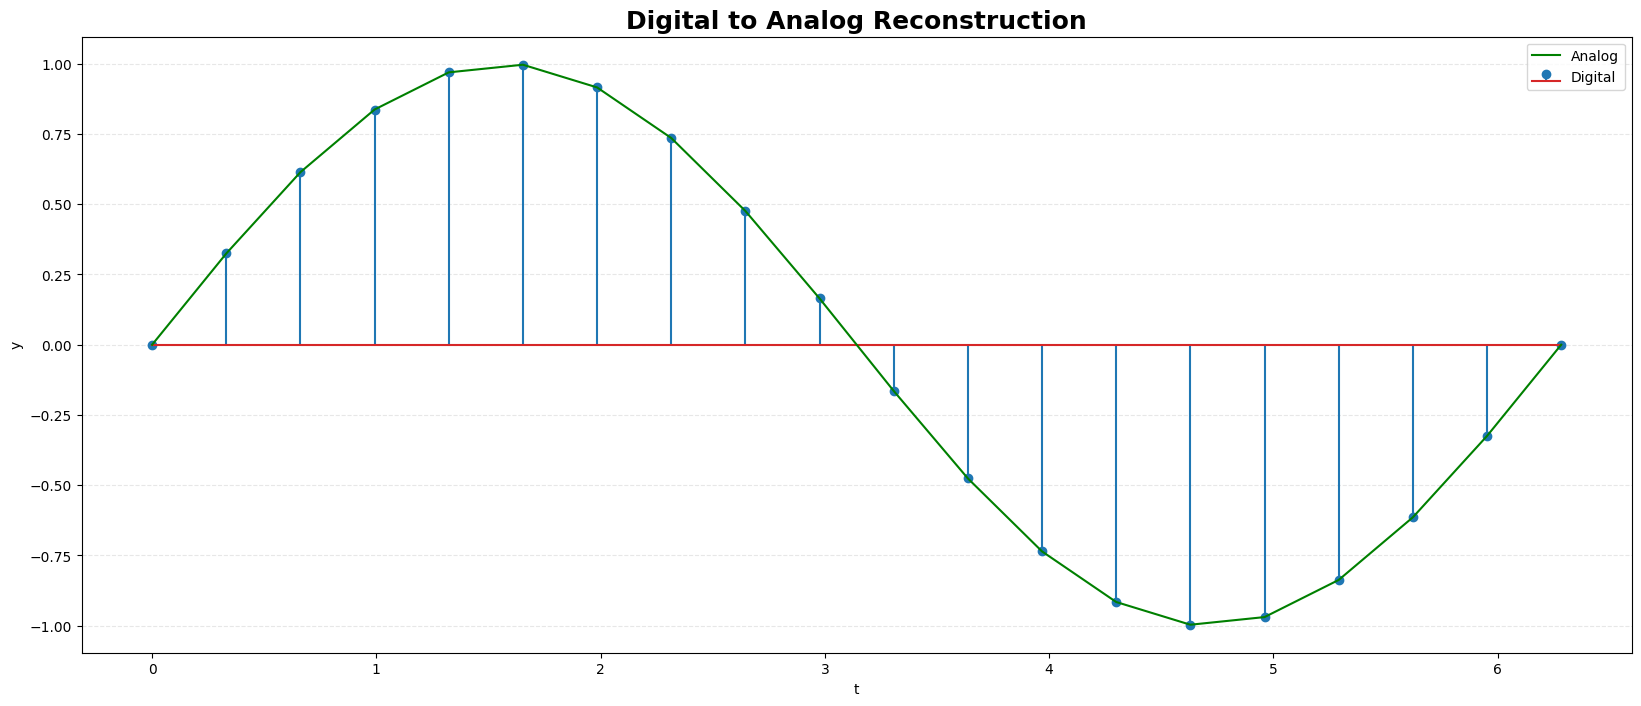

In [35]:
#plot of digital signal
N=20
t=np.linspace(0,2*np.pi,N)
y=np.sin(t)
y_interp=interp1d(t,y,kind='quadratic')
y_interp_values=y_interp(t)
fig,ax=plt.subplots(figsize=(20,8))
plt.stem(t,y,label="Digital")
plt.plot(t,y_interp_values,label="Analog",color="green")
plt.legend()
plt.title("Digital to Analog Reconstruction",fontdict={'fontsize':18,'fontweight':'bold','color':'black'})
plt.xlabel("t")
plt.ylabel("y")
plt.grid(True,axis='y',linestyle="--",alpha=0.3)
plt.show()

In [41]:

# 2. Provide your data points
x_data = [1, 2, 4, 5]
y_data = [1, 4, 2, 5]

# 3. Generate a Cubic Spline (degree = 3)
spline_expr = interpolating_spline(3, x, x_data, y_data)
spline_expr

Piecewise((2*x**3/3 - 6*x**2 + 49*x/3 - 10, (x >= 1) & (x <= 5)))

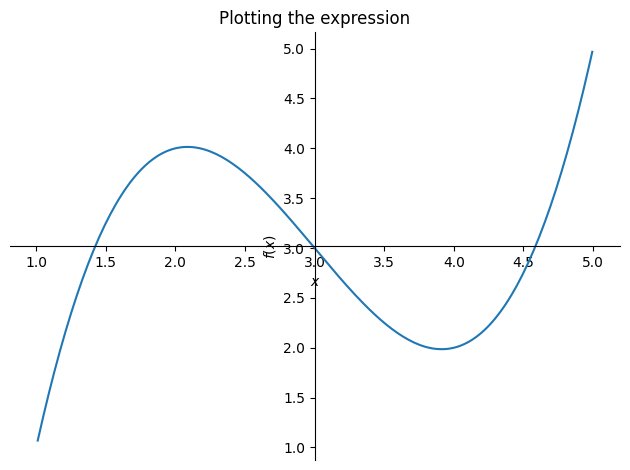

In [48]:
#plotting the function
sp.plot(spline_expr,title="Plotting the expression")
plt.show()

In [49]:

# Define data points as (x, y) tuples
points = [(-1, 3), (0, -4), (1, 5), (2, -6)]

# Generate the interpolating polynomial
poly = interpolate(points, x)
poly

-6*x**3 + 8*x**2 + 7*x - 4

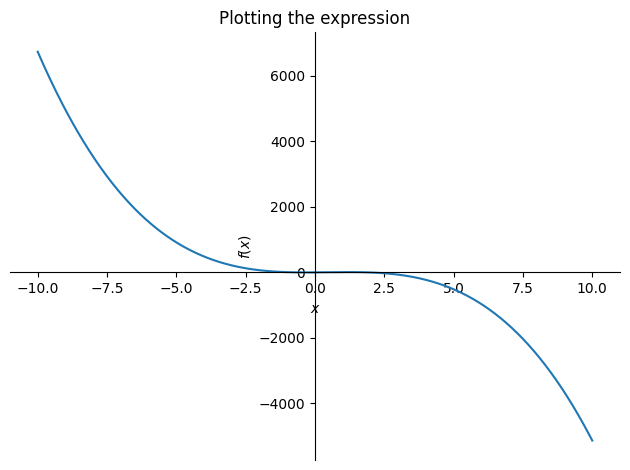

In [50]:
#plotting the function
sp.plot(poly,title="Plotting the expression")
plt.show()

In [56]:
import sympy as sp

i,x= sp.symbols('i,x')
# Computes 1 * 2 * 3 * 4 * 5
sp.summation(x**i, (i, 1, 5))
# Output: 120


x**5 + x**4 + x**3 + x**2 + x